In [ ]:
# Notebook 07: Diabetes Dataset Exploratory Data Analysis

## MSc Data Science and Analytics

### Explainable Machine Learning versus Deep Learning for Early Disease Prediction: A Multi-Dataset Comparative Study

This notebook performs exploratory data analysis on the Pima Indians Diabetes Dataset. The objective is to understand the dataset structure,
identify missing values and potential data quality issues, explore feature distributions, and examine relationships between clinical variables
prior to model development.

In [ ]:
## Objectives

The objectives of this notebook are to:

- Load the Pima Indians Diabetes dataset.
- Explore dataset dimensions and feature information.
- Identify missing values and duplicate records.
- Generate descriptive statistics.
- Analyse feature distributions.
- Examine class distribution.
- Visualise feature correlations.
- Identify potential preprocessing requirements.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"

RAW_PATH = DATA_PATH / "raw" / "diabetes"

FIGURES_PATH = PROJECT_ROOT / "Figures"

FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
list(RAW_PATH.iterdir())

[WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/data/raw/diabetes/diabetes.csv.csv')]

In [4]:
df = pd.read_csv(
    RAW_PATH / "diabetes.csv.csv"
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
## Dataset Overview

The Pima Indians Diabetes Dataset contains diagnostic medical information collected from female patients of Pima Indian heritage.
The objective is to predict whether a patient has diabetes based on diagnostic measurements.

The dataset contains several clinical variables including glucose concentration, blood pressure, skin thickness, insulin level,
body mass index (BMI), diabetes pedigree function, age, and the diabetes outcome.

In [5]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
## Interpretation

The Pima Indians Diabetes dataset contains **768 patient records** and **9 variables**, including eight clinical predictor variables
and one binary target variable (`Outcome`).

There are **no missing values reported** by `df.info()`. However, this dataset is known to use **zero values** in several
clinical measurements (e.g., Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI) to represent missing or unavailable observations.
These values will be identified and handled during the preprocessing stage.

The dataset contains a mixture of integer and floating-point variables, making it suitable for machine learning classification after
appropriate preprocessing.

In [8]:
missing = (df[[
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]] == 0).sum()

missing

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [9]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [ ]:
## Missing Values

Although the dataset contains no explicit missing values, several clinical measurements use zero values to represent unavailable or missing observations.

The highest number of missing values is observed in the **Insulin** and **SkinThickness** variables. These values will be treated
as missing and appropriately imputed during the preprocessing stage.

No duplicate patient records were identified in the dataset.

In [10]:
print(df["Outcome"].value_counts())

print()

print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [ ]:
## Interpretation

The dataset contains **500 non-diabetic patients (65.10%)** and **268 diabetic patients (34.90%)**.

This indicates a **moderate class imbalance**, with the majority class representing non-diabetic patients.
Although the imbalance is not severe, it should be considered during model evaluation by using performance metrics such as Precision,
Recall, F1-score, and ROC-AUC rather than relying solely on accuracy.

Stratified sampling will be used during the train-test split in the modelling notebook to preserve the class distribution
in both training and testing datasets.

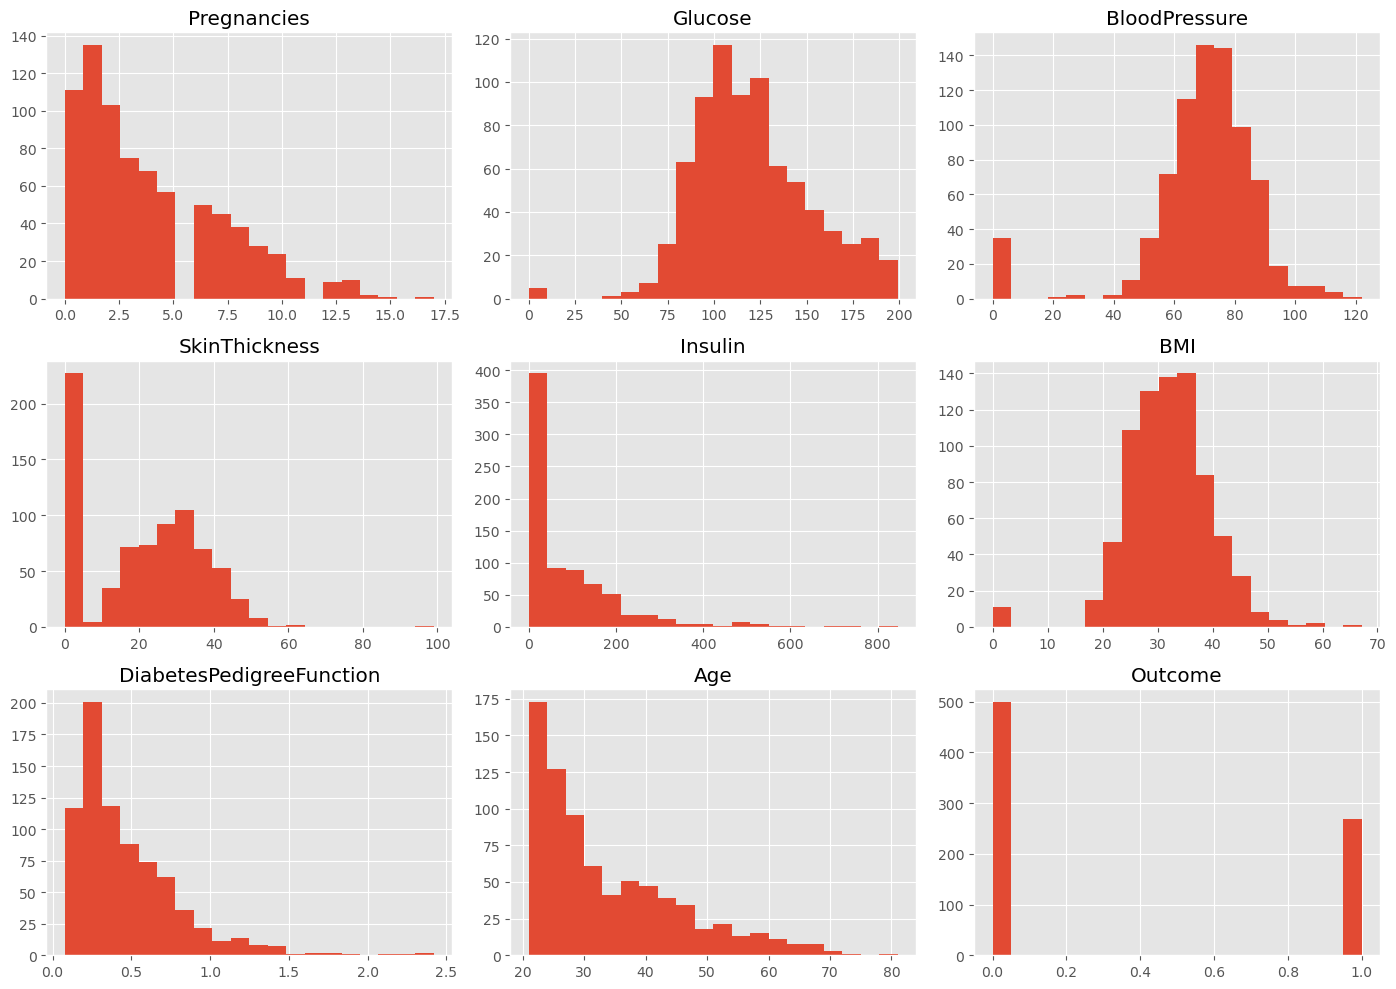

In [11]:
df.hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "diabetes_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

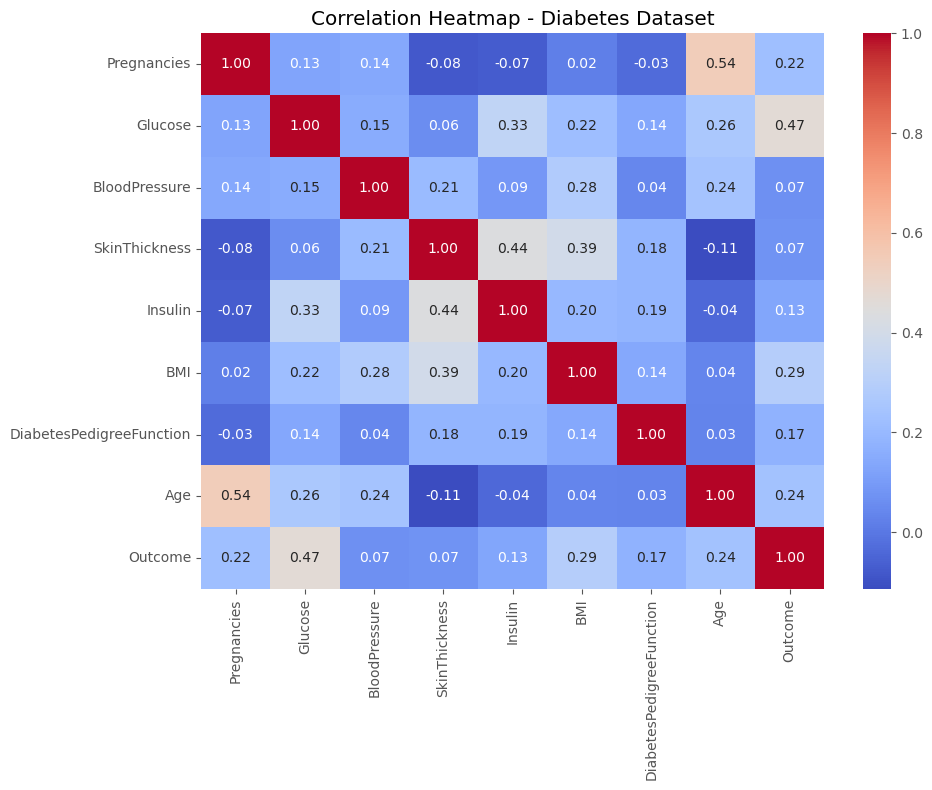

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Diabetes Dataset")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "diabetes_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

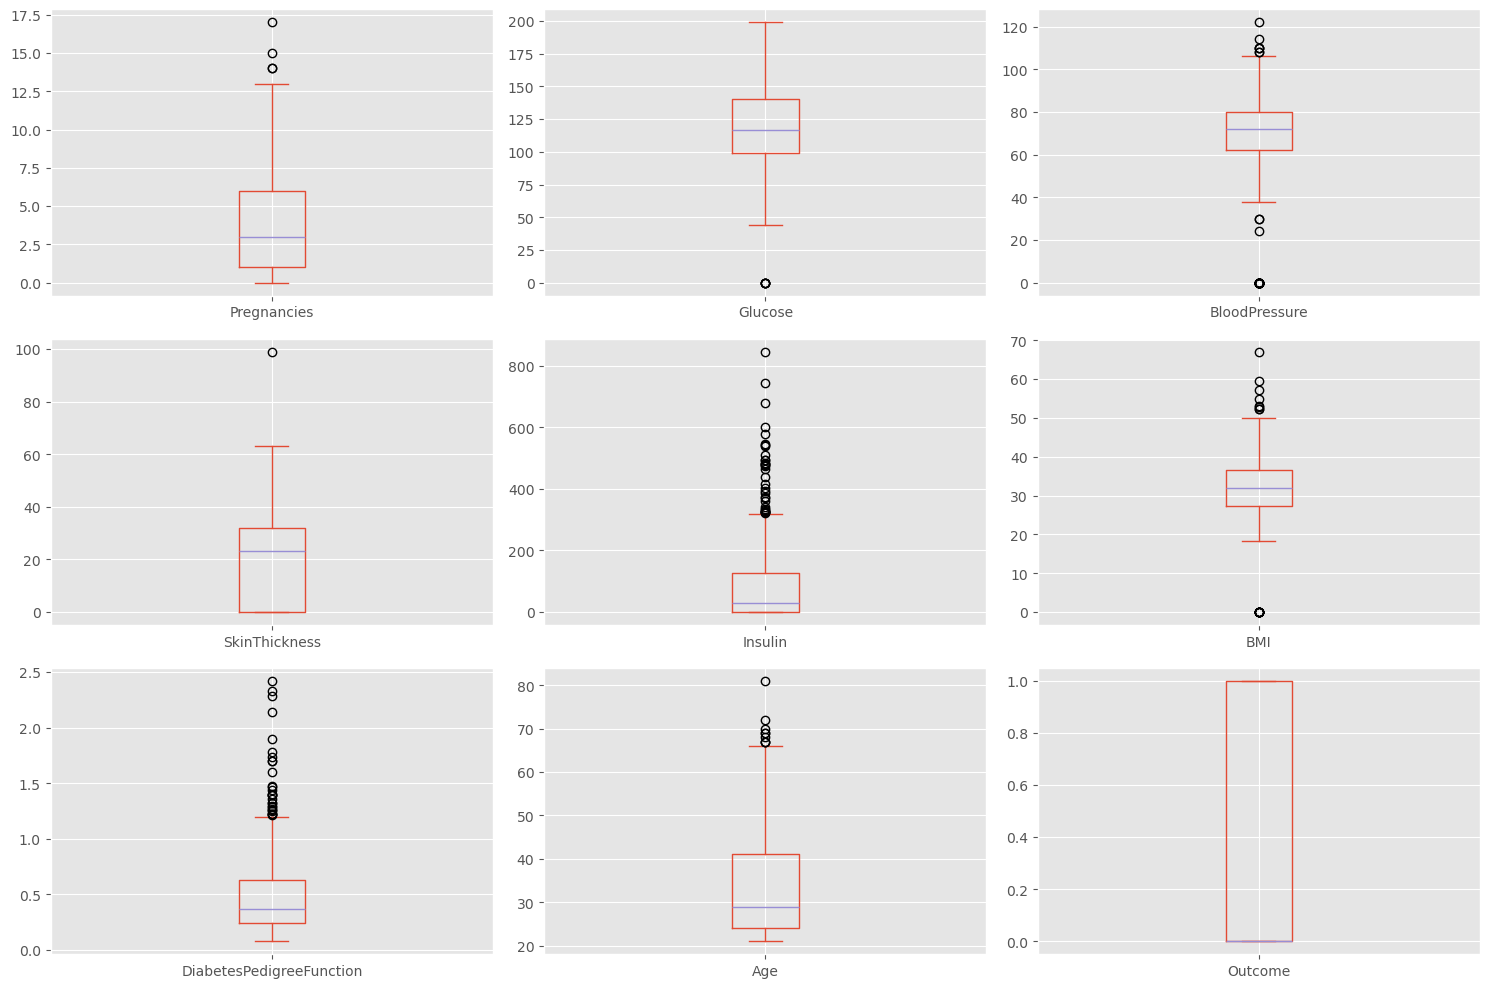

In [13]:
df.plot(
    kind="box",
    subplots=True,
    layout=(3,3),
    figsize=(15,10),
    sharex=False,
    sharey=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "diabetes_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Key Findings

The exploratory data analysis of the Pima Indians Diabetes dataset revealed the following:

- The dataset contains **768 patient records** and **9 variables**.
- No explicit missing values were reported; however, zero values in several clinical variables represent missing measurements.
- The highest number of missing observations occurred in the **Insulin** and **SkinThickness** features.
- No duplicate records were identified.
- The target variable exhibits a moderate class imbalance, with approximately **65% non-diabetic** and **35% diabetic** patients.
- Correlation analysis indicates that **Glucose**, **BMI**, and **Age** are among the variables most strongly associated with diabetes outcome.
- Several variables contain potential outliers, which will be handled appropriately during preprocessing and model development.

In [ ]:
# Conclusion

This notebook explored the structure and characteristics of the Pima Indians Diabetes dataset. The analysis identified data quality issues
related to zero-valued clinical measurements and confirmed a moderate class imbalance.

These findings provide the basis for the next stage of the project, where missing values will be imputed,
the data will be preprocessed, and multiple machine learning and deep learning models will be developed and evaluated for diabetes prediction.